# Computational Social Science Project #3 

**Enter your Name:** Max Dunsker and Lara Pesce Ares

*Semester:* Fall 2025

## 1. Introduction

### Load libraries and data 

In [1]:
#
# load libraries
# -----------
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', None)
import seaborn as sns
from matplotlib import pyplot
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.preprocessing import LabelBinarizer

# There are a few warnings that will appear that will not affect your analysis. Run this code to ignore. 
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# Load model libraries
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

# Make sure to import other libraries that will be necessary for training models!
from sklearn.metrics import confusion_matrix, make_scorer, accuracy_score, recall_score, precision_score, f1_score, classification_report
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_validate, cross_val_score, cross_val_predict
from sklearn.datasets import make_classification
from sklearn import tree



In [2]:
#
# read in "Inspections Data 2011-2013" csv data
# -----------
chicago_inspections_2011_to_2013 = pd.read_csv("data/Chicago Inspections 2011-2013.csv", 
                                              low_memory=False)

# read in  "Inspections Data 2014_updated" csv data
# -----------
chicago_inspections_2014 = pd.read_csv("data/Chicago Inspections 2014_updated.csv",  # be sure to use the "updated" data here
                                      low_memory=False)

In [3]:
# look at the inspections data
chicago_inspections_2011_to_2013.head()

,Inspection_ID,Inspection_Date,DBA_Name,AKA_Name,License,Facility_Type,Risk,Address,City,State,Zip,Inspection_Type,Results,Latitude,Longitude,Location,Facility_Type_Clean,criticalCount,seriousCount,minorCount,pass_flag,fail_flag,pastFail,pastCritical,pastSerious,pastMinor,timeSinceLast,firstRecord,ID,LICENSE_ID,ACCOUNT_NUMBER,LEGAL_NAME,DOING_BUSINESS_AS_NAME,ADDRESS,CITY,STATE,ZIP_CODE,WARD,PRECINCT,WARD_PRECINCT,POLICE_DISTRICT,LICENSE_CODE,LICENSE_DESCRIPTION,BUSINESS_ACTIVITY_ID,BUSINESS_ACTIVITY,LICENSE_NUMBER,APPLICATION_TYPE,LICENSE_TERM_START_DATE,LICENSE_TERM_EXPIRATION_DATE,LICENSE_STATUS,LATITUDE,LONGITUDE,minDate,maxDate,ageAtInspection,consumption_on_premises_incidental_activity,tobacco,package_goods,outdoor_patio,public_place_of_amusement,limited_business_license,childrens_services_facility_license,tavern,regulated_business_license,filling_station,caterers_liquor_license,mobile_food_license,precipIntensity,temperatureMax,windSpeed,humidity,heat_burglary,heat_garbage,heat_sanitation,criticalFound
0,269961,2013-01-31,SEVEN STAR,SEVEN STAR,30790,Grocery Store,Risk 3 (Low),3352 N BROADWAY,CHICAGO,IL,60657.0,Canvass,Pass,41.943359,-87.644999,"(41.943359344775146, -87.64499875300952)",Other,0,0,2,1,0,0,0,0,0,2.0,1,30790-20110416,2081412.0,63759.0,VIRGINIA DELA ROSA,SEVEN STAR,3352 N BROADWAY 1,CHICAGO,IL,60657.0,44.0,33.0,44-33,19.0,1006.0,Retail Food Establishment,775,Retail Sales of Perishable Foods,30790.0,RENEW,2011-04-16,2013-04-15,AAI,41.943359,-87.644999,2002-02-16,2015-04-15,10.964384,0,1,0,0,0,1,0,0,0,0,0,0,0.014587,53.496667,13.340000,0.900000,26.992376,12.768572,37.748787,0
1,507211,2011-10-18,PANERA BREAD,PANERA BREAD,1475890,Restaurant,Risk 1 (High),6059 N LINCOLN AVE,CHICAGO,IL,60659.0,Canvass,Pass,41.991919,-87.709631,"(41.99191947239194, -87.70963133440333)",Restaurant,0,0,3,1,0,0,0,0,0,2.0,1,1475890-20110416,2081695.0,207283.0,"PANERA, LLC",PANERA BREAD,6059 N LINCOLN AVE C,CHICAGO,IL,60659.0,50.0,23.0,50-23,24.0,1006.0,Retail Food Establishment,775,Retail Sales of Perishable Foods,1475890.0,RENEW,2011-04-16,2013-04-15,AAI,41.991919,-87.709631,2004-05-05,2019-04-15,7.457534,0,0,0,0,0,0,0,0,0,0,0,0,0.001907,59.046667,13.016667,0.550000,13.976557,12.895485,15.412267,0
2,507212,2011-10-18,LITTLE QUIAPO RESTAURANT,LITTLE QUIAPO RESTAURANT,1740130,Restaurant,Risk 1 (High),6259 N MCCORMICK RD,CHICAGO,IL,60659.0,Canvass,Fail,41.995632,-87.712707,"(41.99563177556418, -87.71270678169132)",Restaurant,0,2,6,0,1,0,0,0,0,2.0,1,1740130-20110216,2070145.0,3107.0,ENELITA GARCIA,LITTLE QUIAPO RESTAURANT,6259 N MCCORMICK RD,CHICAGO,IL,60659.0,50.0,25.0,50-25,17.0,1006.0,Retail Food Establishment,775,Retail Sales of Perishable Foods,1740130.0,RENEW,2011-02-16,2013-02-15,AAI,41.995632,-87.712707,2007-03-22,2017-02-15,4.578082,0,0,0,0,0,0,0,0,0,0,0,0,0.001907,59.046667,13.016667,0.550000,12.611239,8.004220,8.320330,0
3,507216,2011-10-19,SERGIO'S TAQUERIA PIZZA INC.,SERGIO'S TAQUERIA PIZZA,1447363,Restaurant,Risk 1 (High),3253 W BRYN MAWR AVE,CHICAGO,IL,60659.0,Canvass,Pass,41.982933,-87.710982,"(41.982933189164974, -87.71098225381141)",Restaurant,0,0,6,1,0,0,0,0,0,2.0,1,1447363-20110216,2071895.0,270993.0,SERGIO'S TAZUERIA PIZZA INC.,SERGIO'S TAQUERIA PIZZA INC.,3253 W BRYN MAWR AVE,CHICAGO,IL,60659.0,39.0,48.0,39-48,17.0,1006.0,Retail Food Establishment,775,Retail Sales of Perishable Foods,1447363.0,RENEW,2011-02-16,2013-02-15,AAI,41.982933,-87.710982,2003-12-31,2019-02-15,7.805479,0,0,0,0,0,0,0,0,0,0,0,0,0.002737,56.153333,10.863333,0.616667,35.906383,26.238645,38.186618,0
4,507219,2011-10-20,TARGET STORE # T-2079,TARGET,1679459,Restaurant,Risk 2 (Medium),2112 W PETERSON AVE,CHICAGO,IL,60659.0,Canvass,Fail,41.990729,-87.682979,"(41.99072921796059, -87.68297945359863)",Restaurant,0,2,6,0,1,0,0,0,0,2.0,1,1679459-20100216,2009972.0,15538.0,TARGET CORPORATION,TARGET STORE # T-2079,2112 W PETERSON AVE,CHICAGO,IL,60659.0,40.0,18.0,40-18,24.0,1006.0,Retail Food Establishment,775,Retail Sales of Perishable Foods,1679459.0,RENEW,

In [4]:
# list column names
chicago_inspections_2011_to_2013.columns

Index(['Inspection_ID', 'Inspection_Date', 'DBA_Name', 'AKA_Name', 'License',
       'Facility_Type', 'Risk', 'Address', 'City', 'State', 'Zip',
       'Inspection_Type', 'Results', 'Latitude', 'Longitude', 'Location',
       'Facility_Type_Clean', 'criticalCount', 'seriousCount', 'minorCount',
       'pass_flag', 'fail_flag', 'pastFail', 'pastCritical', 'pastSerious',
       'pastMinor', 'timeSinceLast', 'firstRecord', 'ID', 'LICENSE_ID',
       'ACCOUNT_NUMBER', 'LEGAL_NAME', 'DOING_BUSINESS_AS_NAME', 'ADDRESS',
       'CITY', 'STATE', 'ZIP_CODE', 'WARD', 'PRECINCT', 'WARD_PRECINCT',
       'POLICE_DISTRICT', 'LICENSE_CODE', 'LICENSE_DESCRIPTION',
       'BUSINESS_ACTIVITY_ID', 'BUSINESS_ACTIVITY', 'LICENSE_NUMBER',
       'APPLICATION_TYPE', 'LICENSE_TERM_START_DATE',
       'LICENSE_TERM_EXPIRATION_DATE', 'LICENSE_STATUS', 'LATITUDE',
       'LONGITUDE', 'minDate', 'maxDate', 'ageAtInspection',
       'consumption_on_premises_incidental_activity', 'tobacco',
       'package_goods',

In [5]:
# drop column names related to geography, identification, and pass/fail flags that perfectly predict the outcome
chicago_inspections_2011_to_2013.drop(columns = ['AKA_Name', 
                                                 'License',
                                                 'Address',
                                                 'City',
                                                 'State',
                                                 'Zip',
                                                 'Latitude',
                                                 'Longitude',
                                                 'Location',
                                                 'ID',
                                                 'LICENSE_ID',
                                                 'LICENSE_TERM_START_DATE',
                                                 'LICENSE_TERM_EXPIRATION_DATE',
                                                 'LICENSE_STATUS',
                                                 'ACCOUNT_NUMBER',
                                                 'LEGAL_NAME',
                                                 'DOING_BUSINESS_AS_NAME',
                                                 'ADDRESS',
                                                 'CITY',
                                                 'STATE',
                                                 'ZIP_CODE',
                                                 'WARD',
                                                 'PRECINCT',
                                                 'LICENSE_CODE',
                                                 'BUSINESS_ACTIVITY_ID',
                                                 'BUSINESS_ACTIVITY',
                                                 'LICENSE_NUMBER',
                                                 'LATITUDE',
                                                 'LONGITUDE',
                                                 'pass_flag',
                                                 'fail_flag'],
                                     inplace = True)

# set index
chicago_inspections_2011_to_2013.set_index(['Inspection_ID', 'DBA_Name'], inplace = True)

In [6]:
# convert the inspection date to a datetime format
chicago_inspections_2011_to_2013['Inspection_Date'] = pd.to_datetime(chicago_inspections_2011_to_2013['Inspection_Date'])  

### Visualization

Let's visualize what inspections look like over time.

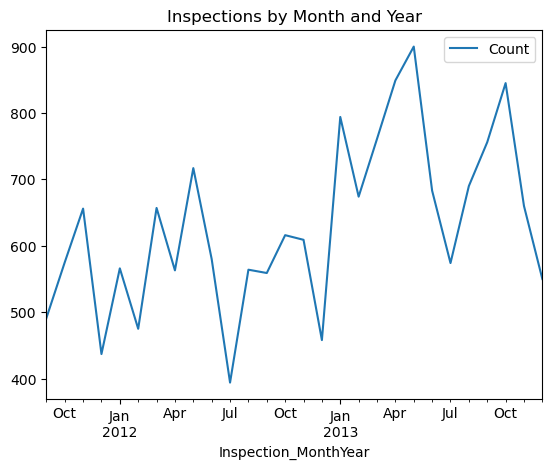

In [7]:
# visualize inspections over time
# -----------
chicago_inspections_2011_to_2013['Inspection_MonthYear'] = chicago_inspections_2011_to_2013['Inspection_Date'].dt.to_period('M')
counts_by_day = chicago_inspections_2011_to_2013.groupby('Inspection_MonthYear').count().rename(columns = {'Facility_Type': 'Count'})['Count'].reset_index()
counts_by_day.set_index(["Inspection_MonthYear"], inplace = True);
counts_by_day.plot(title = "Inspections by Month and Year");

plt.show()

Let's visualize what the distribution of results looks like.

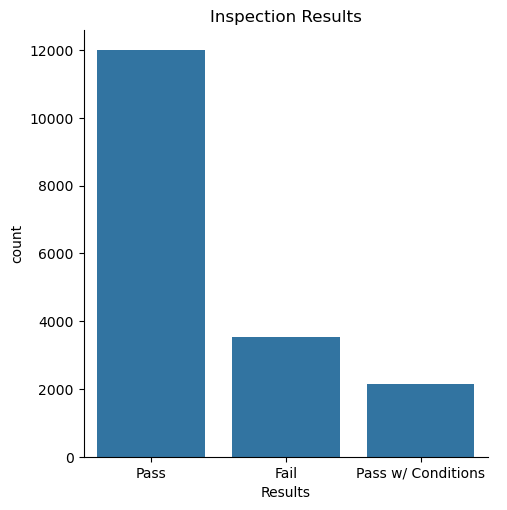

In [8]:
# view inspection results
# -----------
sns.catplot(data = chicago_inspections_2011_to_2013,
           x = "Results",
           kind = "count")

plt.title("Inspection Results")
plt.show()

What if we separate results by facility type?

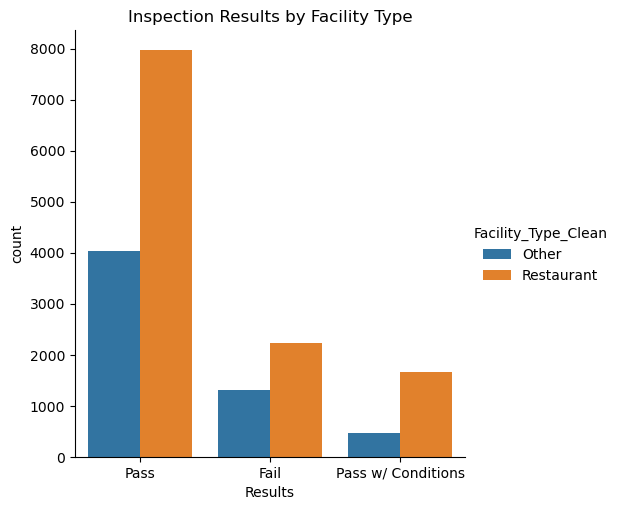

In [9]:
# view inspection results by facility type (restaurant or not)
# -----------
sns.catplot(data = chicago_inspections_2011_to_2013,
            x = "Results",
            kind = "count",
            hue = 'Facility_Type_Clean')

plt.title("Inspection Results by Facility Type");
plt.show()

## 2. Data Preprocessing and Cleaning

In [10]:
# drop datetime info
# -----------
chicago_inspections_2011_to_2013 = chicago_inspections_2011_to_2013.dropna().drop(['Inspection_Date',
                                                                                   'minDate',
                                                                                   'maxDate',
                                                                                   'Inspection_MonthYear'],
                                                                                  axis = 1)

In [11]:
# process target 
# -----------
y = chicago_inspections_2011_to_2013['Results']

# binarize the outcome variable 
y = y.replace({'Pass w/ Conditions': 'Pass'})
lb_style = LabelBinarizer()
y = lb_style.fit_transform(y)

# recode 0s and 1s so 1s are "Fail"
y = np.where(y == 1, 0 ,1)

# process features
# -----------

# create feature dataset
X = chicago_inspections_2011_to_2013.drop(columns = ['Results', 
                                                     'Facility_Type', 
                                                     'LICENSE_DESCRIPTION', 
                                                     'WARD_PRECINCT'])

# get dummies
X = pd.get_dummies(X)

In [12]:
# view feature dataset
X.head()

,,criticalCount,seriousCount,minorCount,pastFail,pastCritical,pastSerious,pastMinor,timeSinceLast,firstRecord,POLICE_DISTRICT,ageAtInspection,consumption_on_premises_incidental_activity,tobacco,package_goods,outdoor_patio,public_place_of_amusement,limited_business_license,childrens_services_facility_license,tavern,regulated_business_license,filling_station,caterers_liquor_license,mobile_food_license,precipIntensity,temperatureMax,windSpeed,humidity,heat_burglary,heat_garbage,heat_sanitation,criticalFound,Risk_Risk 1 (High),Risk_Risk 2 (Medium),Risk_Risk 3 (Low),Inspection_Type_Canvass,Facility_Type_Clean_Other,Facility_Type_Clean_Restaurant,APPLICATION_TYPE_C_EXPA,APPLICATION_TYPE_C_LOC,APPLICATION_TYPE_ISSUE,APPLICATION_TYPE_RENEW
Inspection_ID,DBA_Name,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
269961,SEVEN STAR,0,0,2,0,0,0,0,2.0,1,19.0,10.964384,0,1,0,0,0,1,0,0,0,0,0,0,0.014587,53.496667,13.340000,0.900000,26.992376,12.768572,37.748787,0,False,False,True,True,True,False,False,False,False,True
507211,PANERA BREAD,0,0,3,0,0,0,0,2.0,1,24.0,7.457534,0,0,0,0,0,0,0,0,0,0,0,0,0.001907,59.046667,13.016667,0.550000,13.976557,12.895485,15.412267,0,True,False,False,True,False,True,False,False,False,True
507212,LITTLE QUIAPO RESTAURANT,0,2,6,0,0,0,0,2.0,1,17.0,4.578082,0,0,0,0,0,0,0,0,0,0,0,0,0.001907,59.046667,13.016667,0.550000,12.611239,8.004220,8.320330,0,True,False,False,True,False,True,False,False,False,True
507216,SERGIO'S TAQUERIA PIZZA INC.,0,0,6,0,0,0,0,2.0,1,17.0,7.805479,0,0,0,0,0,0,0,0,0,0,0,0,0.002737,56.153333,10.863333,0.616667,35.906383,26.238645,38.186618,0,True,False,False,True,False,True,False,False,False,True
507219,TARGET STORE # T-2079,0,2,6,0,0,0,0,2.0,1,24.0,5.290411,0,0,1,0,0,1,0,0,0,0,0,0,0.009987,52.730000,16.266667,0.690000,9.530785,3.401567,2.126788,0,False,True,False,True,False,True,False,False,False,True


## 3. Fit Models

Now choose 3 different machine learning techniques and apply them below. Choose from one of the algorithms we have used in lab (e.g., logistic regression, random forests, `AdaBoost()`, `xgboost()`, `VotingClassifer()`, or `BART`). 

Detail the basic logic and assumptions underlying each model, its pros/cons, and why it is a plausible choice for this problem. Also, be sure to do the following:

1. Import the appropriate library from sklearn
2. Set up a hyperparameter grid (check out our previous labs to see how to do this)
3. Find the best hyperparameters, and then fit your model (using either train/validation splits or cross-validation)

In [13]:
# Note, libraries are all imported in first code chunk to keep code clean

# Set scoring criteria to be retrieved
scoring = {
          'accuracy': make_scorer(accuracy_score),
          'recall': make_scorer(recall_score),
          'precision': make_scorer(precision_score),
          'f1': make_scorer(f1_score)
          }

# Get train/validation split for model fitting (test set is 2014)
X_train, X_val, y_train, y_val = train_test_split(X,               # specify features  
                                                    y,               # specify labels 
                                                    train_size = .8, # set training proportional split
                                                    test_size = .2)  # set testing proportional split

# Note, we included confusion matrices at this step of the code to quickly gauge model performance

### Model 1: Logistic Regression

Logistic regression models the probability that an inspection will pass or fail based on other observed factors. It uses a linear combination of predictors that is passed through a logistic (S-shaped) function to keep outputs between 0 and 1. It assumes that the relationship between each predictor and the odds of 0/failure is roughly linear, and that errors are independent. 

The main advantage is interpretability because the coefficients directly show the strength of the effect of individual variables on the failure odds. The main con is that it can lead you to miss complex interactions. Given all this, it is a solid choice as a baseline model for comparison to more advanced models and eventual interpretation of what is driving passage/failure in inspections.

In [14]:
# initialize model and set hyperparameter grid
log_reg = LogisticRegression()

log_reg.get_params()

param_grid = {
    'penalty': ['l1', 'l2'],
    'C': np.arange(.1, 1, .2),
    'fit_intercept': [True, False],
    'solver': ['liblinear', 'saga'],
    'l1_ratio': [0, .5, 1],  # only used for elasticnet
    'max_iter': [100, 200, 500]
}

In [15]:
# execute the grid search
log_grid_reg = RandomizedSearchCV(log_reg, 
                          param_grid, 
                          cv=3,
                          scoring = scoring,
                            refit = 'f1') #refit to best f1 score because it balances recall and precision

# More info on why f1 score is chosen is included in the validation metrics portion of the code

In [16]:
log_grid_reg.fit(X_train, y_train)

log_grid_pred = log_grid_reg.best_estimator_

print(log_grid_reg.best_params_)
print(log_grid_reg.best_score_)

{'solver': 'liblinear', 'penalty': 'l1', 'max_iter': 200, 'l1_ratio': 0.5, 'fit_intercept': False, 'C': np.float64(0.5000000000000001)}
0.8231632208751488


#### Run Confusion Matrix for Logistic Regression to quickly evaluate

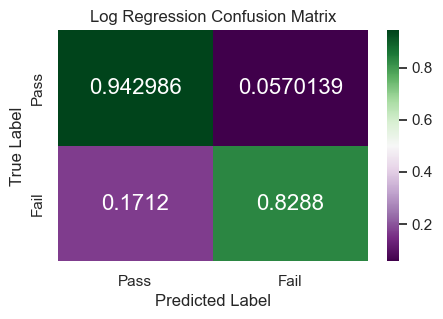

In [17]:
# pull out the predicted values and store as an object
y_pred = log_grid_pred.predict(X_val)

# create confusion matrix
cf_matrix = confusion_matrix(y_val, 
                             y_pred, 
                             normalize = "true")

# turn cf_matrix into a dataframe for plotting purposes
df_cm = pd.DataFrame(cf_matrix)

# label dataframe 
df_cm = df_cm.rename(index   = {0: "Pass", 1: "Fail"}, # label rows
                     columns = {0: "Pass", 1: "Fail"}) # label columns

# plot 
plt.figure(figsize = (5,3))                     # set figure size
sns.set(font_scale=1)                          # set label size

# specify heat map
sns.heatmap(df_cm,                               # specify dataframe                          
           annot=True,                           # display data values       
           annot_kws={"size": 16},               # format data values
           fmt='g',                              # format values as "general"   
           cmap = 'PRGn')                               

# labels 
plt.title("Log Regression Confusion Matrix")                    # label title
plt.xlabel("Predicted Label")                    # label x axis
plt.ylabel("True Label")                         # label y axis     
plt.show()                                       # show label

###  Model 2: Random Forest

Random Forest is an ensemble model that trains a set of decision trees, using bootstrap sampling to supply each decision tree with slightly different datasets. In addition to bootstrap sampling, Random Forest only considers a random subset of the potential predictors in the data at each split; this makes it so the trees are not too correlated. This method can capture the complex interactions that might be missed by a model like logistic regression. Finally, the model looks across all the decision trees to predict the final result.

The main advantages of Random Forest are its ability to handle nonlinearities and interactions within the data and its low risk of overfitting/high variance through using an ensemble of decision trees. The main disadvantage is that it is less interpretable than the logistic regression model or a single decision tree; additionally, when using Gini as the hyperparameter it can lead to misleading feature importance information due its bias towards features that have more categories.

It works in this context because it Random Forest is good for dealing with messy, real-world data that has high dimensionality.

In [18]:
# initialize a random forest classifier
# ----------
rf_classifier = RandomForestClassifier()

param_grid = {
    'n_estimators': [100, 300, 500],          # number of trees
    'criterion': ['gini', 'entropy'],         # splitting metric
    'max_depth': [None, 5, 10, 20, 40],       # tree depth
    'min_samples_split': [2, 5, 10],          # minimum samples to split
    'min_samples_leaf': [1, 2, 4],            # minimum samples at leaf
    'max_features': ['sqrt', 'log2', None],   # features per split
    'max_leaf_nodes': [None, 10, 50, 100],    # optional structure limit
    'min_impurity_decrease': [0.0, 1e-7, 1e-4],  # early stopping regularization
}

In [19]:
# execute the grid search
rf_grid = RandomizedSearchCV(rf_classifier, 
                          param_grid, 
                          cv=3,
                          scoring = scoring,
                            refit = 'f1')

In [20]:
rf_grid.fit(X_train, y_train)

rf_pred = rf_grid.best_estimator_

print(rf_grid.best_params_)
print(rf_grid.best_score_)

{'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 2, 'min_impurity_decrease': 0.0, 'max_leaf_nodes': None, 'max_features': 'sqrt', 'max_depth': None, 'criterion': 'gini'}
0.8373219410505001


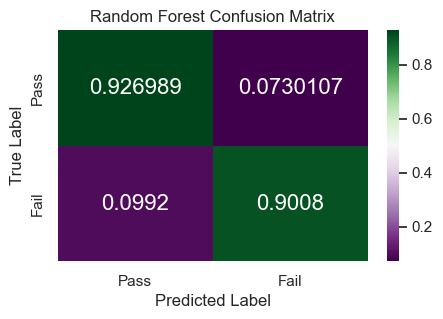

In [21]:
# pull out the predicted values and store as an object
y_pred = rf_pred.predict(X_val)

# specify confusion matrix
cf_matrix = confusion_matrix(y_val,                     # actual targets (ground truth)
                             y_pred,              # estimated targets 
                             normalize = "true")    # normalize confusion matrix over rows and columns # specify confusion matrix

# turn cf_matrix into a dataframe for plotting purposes
df_cm = pd.DataFrame(cf_matrix)

# label dataframe 
df_cm = df_cm.rename(index   = {0: "Pass", 1: "Fail"}, # label rows
                     columns = {0: "Pass", 1: "Fail"}) # label columns

# plot 
plt.figure(figsize = (5,3))                     # set figure size
sns.set(font_scale=1)                          # set label size

# specify heat map
sns.heatmap(df_cm,                               # specify dataframe                          
           annot=True,                           # display data values       
           annot_kws={"size": 16},               # format data values
           fmt='g',                              # format values as "general"      
           cmap = 'PRGn')
            
# labels 
plt.title("Random Forest Confusion Matrix")                    # label title
plt.xlabel("Predicted Label")                    # label x axis
plt.ylabel("True Label")                         # label y axis     
plt.show()                                       # show label

###  Model 3: XGBoost

XGBoost is a high-performance boosting algorithm that builds many shallow decision trees sequentially in order to correct errors made by the other trees. 

The benefit is that it doesn’t rely on linear assumptions and can capture complicated relationships and interactions automatically. It also includes built-in regularization, which helps control overfitting, and it can handle missing data effectively. The cons are that it requires careful tuning and is less interpretable than a simple logistic regression model. 

For this food inspection prediction, it’s a good candidate because the inspection data appears to be noisy and nonlinear, and we want a model that is driving towards the most predictive rather than interpretability.

In [22]:
# initialize an XGBoost classifier
# ----------
xgb_classifier = xgb.XGBClassifier()

param_grid = {
    'n_estimators': [200, 500],         # number of boosting rounds
    'learning_rate': [0.01, 0.05, 0.1], # shrinkage step size
    'max_depth': [3, 5, 7],             # tree depth
    'min_child_weight': [1, 3, 5],      # minimum sum of weights at child node
    'subsample': [0.6, 0.8, 1.0],       # row sampling
    'colsample_bytree': [0.6, 0.8, 1.0],# feature sampling per tree
    'gamma': [0, 1, 5],                 # minimum loss reduction to split
    'reg_alpha': [0, 0.1, 1],           # L1 regularization
    'reg_lambda': [1, 2],               # L2 regularization
}

In [23]:
# execute the grid search
xgb_grid = RandomizedSearchCV(xgb_classifier, 
                          param_grid, 
                          cv=3,
                          scoring = scoring,
                            refit = 'f1')

In [24]:
xgb_grid.fit(X_train, y_train)

xgb_pred = xgb_grid.best_estimator_

print(xgb_grid.best_params_)
print(xgb_grid.best_score_)

{'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 7, 'learning_rate': 0.01, 'gamma': 5, 'colsample_bytree': 1.0}
0.8396308239567704


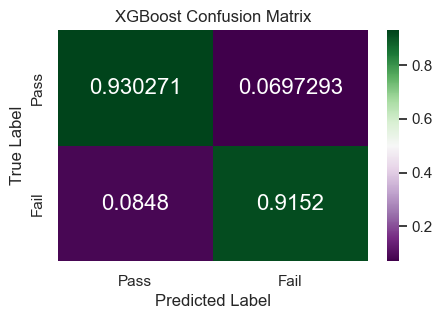

In [25]:
# pull out the predicted values and store as an object
y_pred = xgb_pred.predict(X_val)

# specify confusion matrix
cf_matrix = confusion_matrix(y_val, 
                             y_pred, 
                             normalize = "true")

# turn cf_matrix into a dataframe for plotting purposes
df_cm = pd.DataFrame(cf_matrix)

# label dataframe 
df_cm = df_cm.rename(index   = {0: "Pass", 1: "Fail"}, # label rows
                     columns = {0: "Pass", 1: "Fail"}) # label columns

# plot 
plt.figure(figsize = (5,3))                     # set figure size
sns.set(font_scale=1)                          # set label size

# specify heat map
sns.heatmap(df_cm,                               # specify dataframe                          
           annot=True,                           # display data values       
           annot_kws={"size": 16},               # format data values
           fmt='g',                              # format values as "general"      
           cmap = 'PRGn')

# labels 
plt.title("XGBoost Confusion Matrix")                    # label title
plt.xlabel("Predicted Label")                    # label x axis
plt.ylabel("True Label")                         # label y axis     
plt.show()                                       # show label

### Validation Metrics

Be sure to explain which of these metrics you would want to prioritize when conducting predictive auditing in this context and why.

**Hint**: Try writing a for loop to use [`cross_val_score()`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html) to check for accuracy, precision, recall and f1 across all of your models.

In [26]:
# Create dictionary of models for loop
models = {
    "Logistic Regression": log_grid_pred,
    "Random Forest": rf_pred,
    "XGBoost": xgb_pred
}

In [27]:
# Predict on test set and print the results for accuracy, recall, precision, and F1 score

for name, model in models.items():
    print(f"**{name}**")
    y_pred = model.predict(X_val)
    print("Accuracy:", round(accuracy_score(y_val, y_pred),3))
    print("Precision:", round(precision_score(y_val, y_pred),3))
    print("Recall:", round(recall_score(y_val, y_pred),3))
    print("F1:", round(f1_score(y_val, y_pred),3))
    print()

**Logistic Regression**
Accuracy: 0.92
Precision: 0.788
Recall: 0.829
F1: 0.808

**Random Forest**
Accuracy: 0.922
Precision: 0.76
Recall: 0.901
F1: 0.824

**XGBoost**
Accuracy: 0.927
Precision: 0.771
Recall: 0.915
F1: 0.837



It is tough to say which performance metric matters most because it depends if the department cares more about minimizing the cost of the audits or catching all the possible violators. 

If cost minimization is most important, **precision** is the performance metric to focus on because it prioritizes the correctedness (true positives) and punishes false positives, which in this case would represent wasted resources. If catching all possible violators is most important, **recall** would be the metric as it still rewards true positives but instead punishes for false negatives, which in this case would be unflagged violating business. Random Forest is the model with the highest recall score. **In this case, because the exact priority of the city is unknown, we will use F1 score** because it penalizes false positives and false negatives equally, balancing the need to conserve resources with the urgency of catching all violators. 

## 4. Policy Simulation

### Interpretable Machine Learning

Use tools like coefficient plots or feature importance plots to investigate your models. Which features contribute to your predictions? Are there any additional features you wish you could incorporate that you don't have available in this analysis?

**Hint**: Use tools like feature importance plots and coefficient plots.

#### Coefficient Plot for Logistic Regression

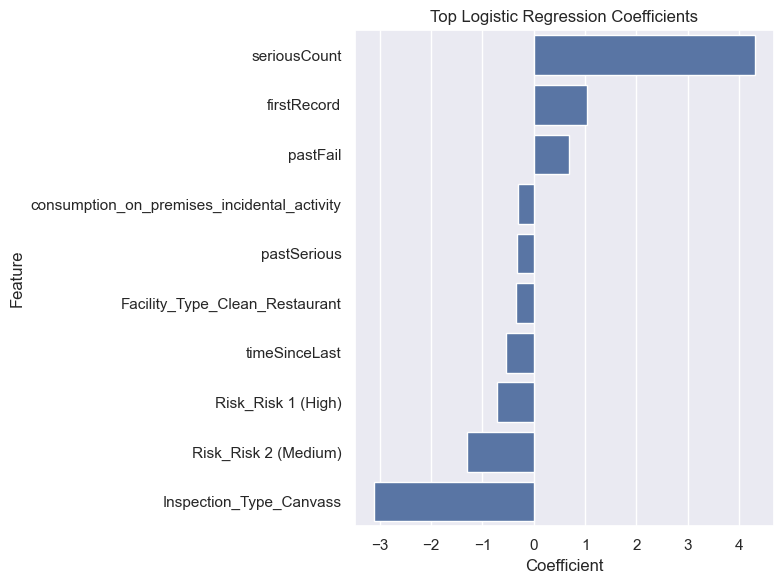

In [28]:
# extract the coefficients and create a dataframe for plotting 
logit_data = pd.concat(
    [
        pd.DataFrame(X_train.columns, columns=["Feature"]),
        pd.DataFrame(log_grid_pred.coef_.T, columns=["Coefficient"])
    ],
    axis=1
)

# add absolute value for ranking
logit_data["abs_coef"] = logit_data["Coefficient"].abs()

# keep top 10 by absolute value of coefficient
top_coef = logit_data.nlargest(10, "abs_coef")

# sort so the smallest appears at the bottom of the plot
top_coef = top_coef.sort_values(by = "Coefficient", ascending=False)

# plot
plt.figure(figsize=(8, 6))
sns.barplot(
    data=top_coef,
    x="Coefficient",
    y="Feature"
)
plt.title("Top Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

#### Coefficient Plot for Random Forest

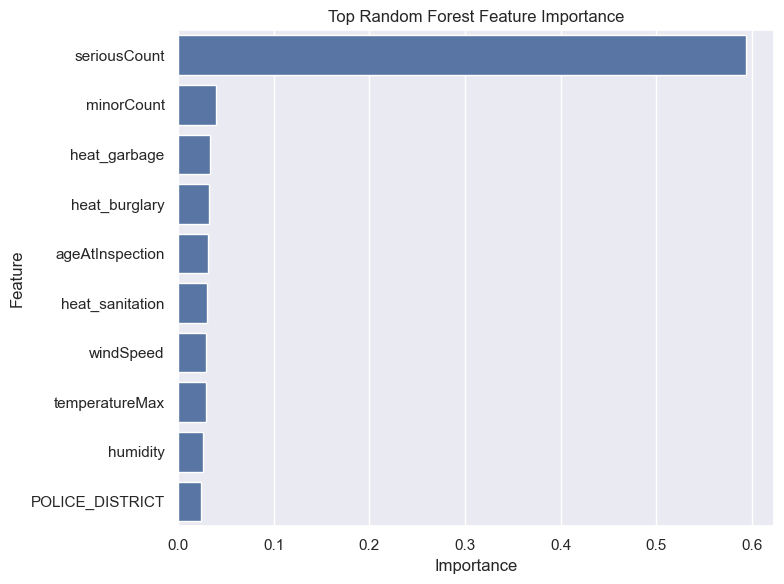

In [29]:
# create feature importance dataframe
rf_data = pd.concat([pd.DataFrame(X_train.columns),
                              pd.DataFrame(np.transpose(rf_pred.feature_importances_))], axis = 1)
rf_data.columns = ["Feature", "Importance"]

# keep top 10 by absolute value of coefficient
top_coef = rf_data.nlargest(10, "Importance")

# sort so the smallest appears at the bottom of the plot
top_coef = top_coef.sort_values(by = "Importance", ascending=False)

# plot
plt.figure(figsize=(8, 6))
sns.barplot(
    data=top_coef,
    x="Importance",
    y="Feature"
)
plt.title("Top Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

#### Coefficient Plot for XGBoost

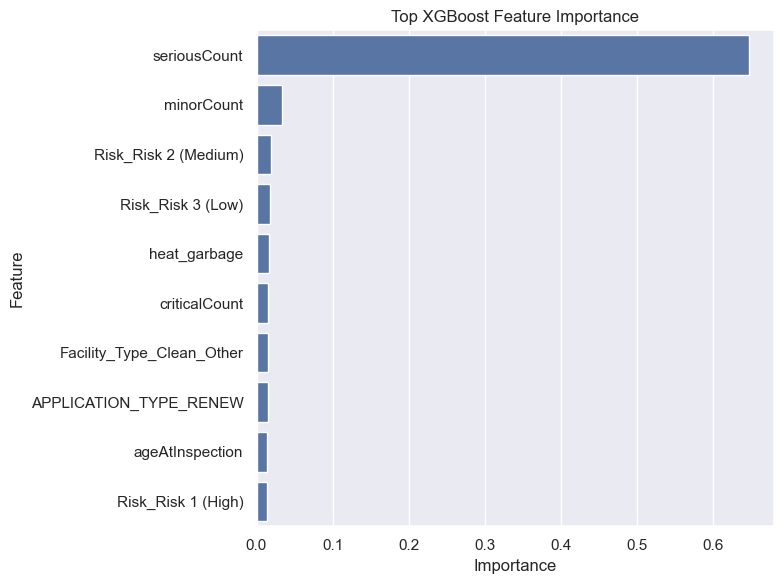

In [30]:
# create feature importance dataframe
xgb_data = pd.concat([pd.DataFrame(X_train.columns),
                              pd.DataFrame(np.transpose(xgb_pred.feature_importances_))], axis = 1)
xgb_data.columns = ["Feature", "Importance"]

# keep top 10 by absolute value of coefficient
top_coef = xgb_data.nlargest(10, "Importance")

# sort so the smallest appears at the bottom of the plot
top_coef = top_coef.sort_values(by = "Importance", ascending=False)

# plot
plt.figure(figsize=(8, 6))
sns.barplot(
    data=top_coef,
    x="Importance",
    y="Feature"
)
plt.title("Top XGBoost Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

#### **Interpretable Machine Learning Discussion**

_Which features contribute to your predictions?_ The count of serious violations is the largest contributor in all three models, the logistic regression shows that it is a positive predictor of failure and that is likely true in the Random Forest and XGBoost models. In logistic regression, if the inspection type was from canvassing then the facility was much less likely to fail the inspection. In both Random Forest and XGBoost, all the other features were much less important than the count of serious violations, though the occurrence/count of critical violations, the count of minor violations, and the heat_garbage score (unable to find what this variable means in this data https://data.cityofchicago.org/Health-Human-Services/Food-Inspections/4ijn-s7e5/about_data) each contributed.

_Are there any additional features you wish you could incorporate that you don't have available in this analysis?_ Some interesting data would have been the number of workers at the facility, whether the establishment was part of a chain or franchise, and maybe the square footage of the establishment, with the idea that the size (in terms of labor, organizationally, or literal footprint) of an establishment may relate to the likelihood of failure.


### Prioritize Audits

**Hint**: Look up the [`.predict()`](https://www.kite.com/python/docs/sklearn.linear_model.SGDRegressor.predict), [`.predict_proba()`](https://www.kite.com/python/docs/sklearn.linear_model.LogisticRegression.predict_proba), and [`.sample()`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.sample.html) methods. Then: 
1. Choose one of your models (or train a new simplified model or ensemble!) to predict outcomes and probabilities. 
2. Order your audits by their probability of detecting a "Fail" score
3. Plot your distribution of pass/fail among the first 1,000 observations in the dataset
4. Simulate random audits on the full chicago_2011_to_2013.csv dataset by picking 1,000 observations at random

**This was confusing, but assumed predictions were supposed to happen on X dataset because of #4.** Chose Random Forest because it always tended to perform well whenever I reran the code.

In [31]:
#
# 1. Choose one of your models (or train a new simplified model or ensemble!) to predict outcomes and probabilities.
# -----------

fail_probability = rf_pred.predict_proba(X)[:, 1]   # probability of "Fail"
fail_prediction = rf_pred.predict(X)

probability_results_df = pd.DataFrame({
    "fail_probability": fail_probability,
    "fail_prediction": fail_prediction,
    "results": y.ravel()
})


In [32]:
#
# 2. Order your audits by their probability of detecting a "Fail" score
# -----------

top_1000 = probability_results_df.sort_values('fail_probability', ascending=False).head(1000)

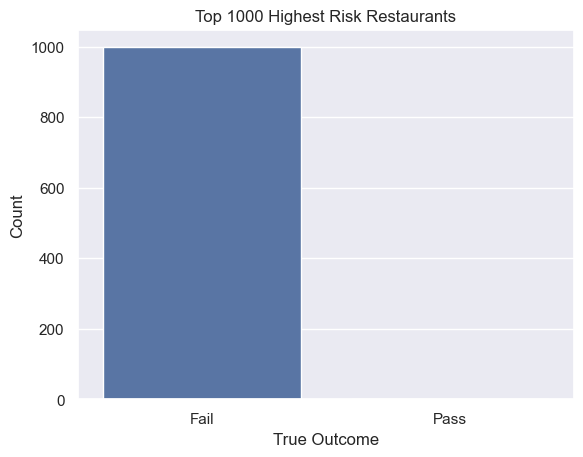

In [33]:
#
# 3. Plot your distribution of pass/fail among the first 1,000 observations in the dataset
# -----------

top_1000_chart = top_1000.copy()

top_1000_chart['results'] = top_1000_chart['results'].map({0: "Pass", 1: "Fail"})
                     
sns.countplot(x='results', data=top_1000_chart)
plt.xlabel('True Outcome')
plt.ylabel('Count')
plt.title('Top 1000 Highest Risk Restaurants')
plt.show()

In [34]:
# F1 Score for top 1000

print("Accuracy:", round(accuracy_score(top_1000['results'], top_1000['fail_prediction']),3))
print("Precision:", round(precision_score(top_1000['results'], top_1000['fail_prediction']),3))
print("Recall Score:", round(recall_score(top_1000['results'], top_1000['fail_prediction']),3))
print("F1 Score:", round(f1_score(top_1000['results'], top_1000['fail_prediction']),3))

top_1000.head()

Accuracy: 0.998
Precision: 0.998
Recall Score: 1.0
F1 Score: 0.999


,fail_probability,fail_prediction,results
2786,0.954021,1,1
14236,0.950375,1,1
3433,0.949780,1,1
13279,0.949725,1,1
10737,0.948850,1,1


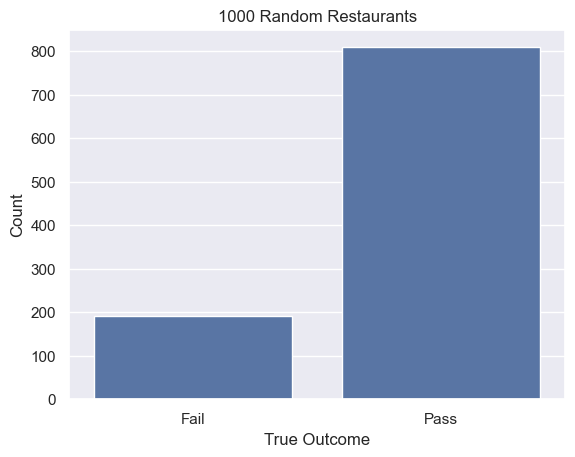

In [35]:
#
# 4. Simulate random audits on the full chicago_2011_to_2013.csv dataset by picking 1,000 observations at random
# -----------

random_1000 = probability_results_df.sample(1000, random_state=13)

random_1000_chart = random_1000.copy()

random_1000_chart['results'] = random_1000_chart['results'].map({0: "Pass", 1: "Fail"})
                     
sns.countplot(x='results', data=random_1000_chart)
plt.xlabel('True Outcome')
plt.ylabel('Count')
plt.title('1000 Random Restaurants')
plt.show()

In [36]:
# F1 Score for random 1000

print("Accuracy:", round(accuracy_score(random_1000['results'], random_1000['fail_prediction']),3))
print("Precision:", round(precision_score(random_1000['results'], random_1000['fail_prediction']),3))
print("Recall Score:", round(recall_score(random_1000['results'], random_1000['fail_prediction']),3))
print("F1 Score:", round(f1_score(random_1000['results'], random_1000['fail_prediction']),3))

random_1000.head()

Accuracy: 0.987
Precision: 0.959
Recall Score: 0.974
F1 Score: 0.966


,fail_probability,fail_prediction,results
13888,0.780836,1,1
6455,0.004983,0,0
439,0.005350,0,0
1905,0.006747,0,0
3283,0.009252,0,0


#### Predictive Auditing Discussion

Predictive auditing was a more effective means versus random auditing, as those that were predicted to fail inspection based on the model failed at a much higher rate than a random sample chosen from the population.

### Predict on 2014 inspection data

Use your favorite model to make predictions based on the features using the "Chicago Inspection 2014_updated.csv" file. Treat this as you would a test dataset. This means you will have to format the features (including removing some features and getting dummies) and the label (binarize and recode) in the same way you did the training data. (Remember the "Results" column is your label). You will then compare your predictions with the actual.

In [37]:
# data processing
# -----------

chicago_inspections_2014_clean = chicago_inspections_2014.copy()

# drop column names related to geography, identification, and pass/fail flags that perfectly predict the outcome
chicago_inspections_2014_clean.drop(columns = ['AKA_Name', 
                                                 'License',
                                                 'Address',
                                                 'City',
                                                 'State',
                                                 'Zip',
                                                 'Latitude',
                                                 'Longitude',
                                                 'Location',
                                                 'ID',
                                                 'LICENSE_ID',
                                                 'LICENSE_TERM_START_DATE',
                                                 'LICENSE_TERM_EXPIRATION_DATE',
                                                 'LICENSE_STATUS',
                                                 'ACCOUNT_NUMBER',
                                                 'LEGAL_NAME',
                                                 'DOING_BUSINESS_AS_NAME',
                                                 'ADDRESS',
                                                 'CITY',
                                                 'STATE',
                                                 'ZIP_CODE',
                                                 'WARD',
                                                 'PRECINCT',
                                                 'LICENSE_CODE',
                                                 'BUSINESS_ACTIVITY_ID',
                                                 'BUSINESS_ACTIVITY',
                                                 'LICENSE_NUMBER',
                                                 'LATITUDE',
                                                 'LONGITUDE',],
                                     inplace = True)

# set index
chicago_inspections_2014_clean.set_index(['Inspection_ID', 'DBA_Name'], inplace = True)


# drop datetime info
# -----------
chicago_inspections_2014_clean = chicago_inspections_2014_clean.dropna().drop(['Inspection_Date',
                                                                                   'minDate',
                                                                                   'maxDate'],
                                                                                  axis = 1)

In [38]:
# process features
X_test2014 = chicago_inspections_2014_clean.drop(columns = ['Results', 
                                                     'Facility_Type', 
                                                     'LICENSE_DESCRIPTION', 
                                                     'WARD_PRECINCT'])
# get dummies
X_test2014 = pd.get_dummies(X_test2014)
X_test2014.head()


# process target 
y_test2014 = chicago_inspections_2014_clean['Results']

# binarizing Results
y_test2014 = y_test2014.replace({'Pass w/ Conditions': 'Pass'})
lb_style = LabelBinarizer()
y_test2014 = lb_style.fit_transform(y_test2014)

# recode 0s and 1s so 1s are "Fail"
y_test2014 = np.where(y_test2014 == 1, 0 ,1)

In [39]:
# predict and compare 
# -----------
y_pred2014 = rf_pred.predict(X_test2014)

2014 F1 score: 0.7891


In [42]:
# evaluate
# -----------

print("2014 Test Set Accuracy:", round(accuracy_score(y_test2014, y_pred2014),3))
print("2014 Test Set Precision:", round(precision_score(y_test2014, y_pred2014),3))
print("2014 Test Set Recall:", round(recall_score(y_test2014, y_pred2014),3))
print("2014 Test Set F1 Score:", round(f1_score(y_test2014, y_pred2014),3))

2014 Test Set Accuracy: 0.908
2014 Test Set Precision: 0.723
2014 Test Set Recall: 0.869
2014 Test Set F1 Score: 0.789


As discussed above, F1 score makes the most sense as the metric to use in the case of food safety audits because it balances the importance of not wasting limited resources of false positives (precision) and minimizing the public health risk by catching as many violating establishments as possible (recall) into one metric. The model performed very well, though of the performance metrics, precision was the lowest. These numbers compare well to the performance metrics in the 2013 training/validation model evaluation section, indicating that the model is not overfit to the known data and would be an effective predictor for future data in real-world implementation.

For the same reasons as discussed above, F1 Score makes the most since in this food inspection scenario because it balances the need to make the best use of limited resources (measured via precision) and the need to catch all violators from a public health perspective (measured via recall). 

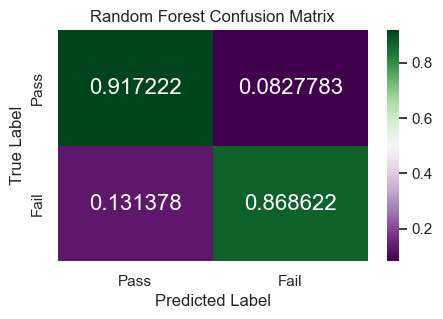

In [43]:
# specify confusion matrix
cf_matrix = confusion_matrix(y_test2014, 
                             y_pred2014, 
                             normalize = "true")

# turn cf_matrix into a dataframe for plotting purposes
df_cm = pd.DataFrame(cf_matrix)

# label dataframe 
df_cm = df_cm.rename(index   = {0: "Pass", 1: "Fail"}, # label rows
                     columns = {0: "Pass", 1: "Fail"}) # label columns

# plot 
plt.figure(figsize = (5,3))                     # set figure size
sns.set(font_scale=1)                          # set label size

# specify heat map
sns.heatmap(df_cm,                               # specify dataframe                          
           annot=True,                           # display data values       
           annot_kws={"size": 16},               # format data values
           fmt='g',                              # format values as "general"      
           cmap = 'PRGn')

# labels 
plt.title("Random Forest Confusion Matrix")                    # label title
plt.xlabel("Predicted Label")                    # label x axis
plt.ylabel("True Label")                         # label y axis     
plt.show()                                       # show label

## 5. Discussion Questions

1. Why do we need metrics beyond accuracy when using machine learning in the social sciences and public policy?


When you only look at accuracy, you can miss important imbalances in how well a model treats different groups or handles the cases you care the most about. In many policy settings, the top priority are the cases that are less common, like facilities that fail inspection, so we need metrics like precision, recall, and F1 to understand whether the model is actually identifying those cases consistently. These metrics help paint the complete picture of tradeoffs between false positives and false negatives, which, in policy setting, have real-world implications that are important to be cognizant of up front. With measures that surface these imbalances, we are able to choose models that minimize waste of limited resource or prioritize necessary interventions depending on the context, which we can't do with accuracy alone.

2. Imagine that establishments learned about the algorithm being used to determine who gets audited and they started adjusting their behavior (and changing certain key features about themselves that were important for the prediction) to avoid detection. How could policymakers address this interplay between algorithmic decisionmaking and real world behavior?

Changes in behavior are a real concern for the implementation of these models in policy settings. Regardless of if the behavior change is as a result of the implementation of the model itself or some other exogenous factor, these systems should not be one-time solutions but instead be integrated into a workflow that regularly retrains models, adjust features, and tests parameters. One approach that can mitigate too much conformation to the model is to incorporate a bit of randomness. In our example implementation for food audits, selecting the highest risk establishments to audit, plus some selected randomly, would prevent establishments from gaming the model by reneging on their obligations based on knowledge that they had a low probability based on their most recent audit.

In terms of the model, policymakers can also consider making sure the model is trained on more immutable characteristics to prevent manipulation from businesses or regularly retrain the model on recent data to account for any manipulation of key features or changing real-world dynamics.